# EDA: Vehicle Insurance Claim Fraud Detection

Exploratory data analysis on `fraud_oracle.csv` for the LexisNexis fraud-scoring project.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

TARGET = "FraudFound_P"

df = pd.read_csv("/content/drive/MyDrive/LexisNexis1A/Data/fraud_oracle.csv")
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [ ]:
# ---- Setup: imports, cleaning, split, helper ----
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

df["Age"] = df["Age"].replace(0, np.nan)   # 0 = placeholder

train = df[df["Year"] <= 1995]
test  = df[df["Year"] == 1996]

def capture_rate(y_true, probs, top_frac):
    y_true = np.asarray(y_true)
    n_review = int(len(y_true) * top_frac)
    top_idx = np.argsort(probs)[::-1][:n_review]
    return y_true[top_idx].sum() / y_true.sum()

print(train.shape, test.shape)

(11337, 33) (4083, 33)


## 1. Basic metrics


Fraud is expected to be a rare class (~6%), which is why this project uses precision/recall/F1/PR-AUC instead of accuracy, a model that always predicts "not fraud" would already be ~94% accurate while catching zero fraud.

In [ ]:
print("Rows, columns:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("\nFraud counts:")
print(df[TARGET].value_counts())
print("\nFraud rate:", round(df[TARGET].mean(), 4))

Rows, columns: (15420, 33)
Missing values: 0

Fraud counts:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Fraud rate: 0.0599


## 2. Class balance



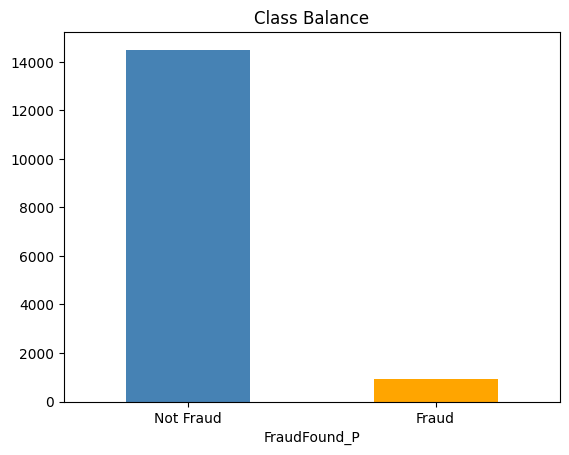

In [ ]:
fig, ax = plt.subplots()
df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color=["steelblue", "orange"])
ax.set_xticklabels(["Not Fraud", "Fraud"], rotation=0)
ax.set_title("Class Balance")
plt.show()

## 3. Age distribution


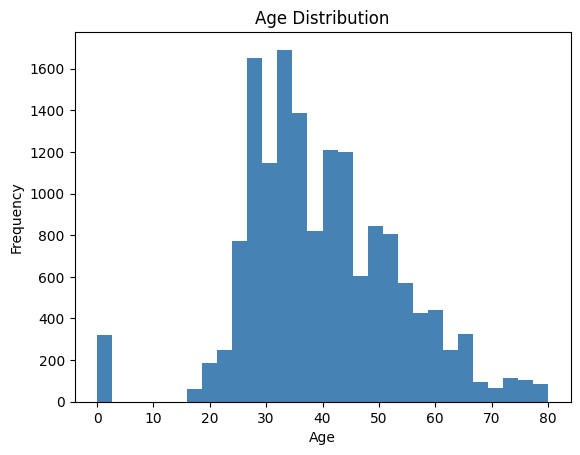

In [ ]:
fig, ax = plt.subplots()
df["Age"].plot(kind="hist", bins=30, ax=ax, color="steelblue")
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
plt.show()

## 4. Fraud rate by vehicle category



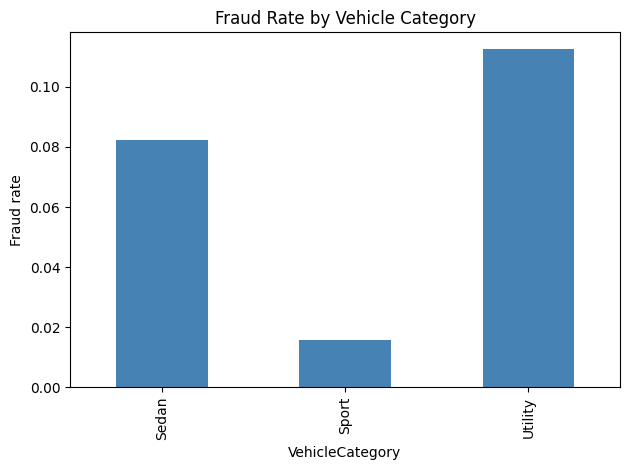

In [ ]:
fig, ax = plt.subplots()
df.groupby("VehicleCategory")[TARGET].mean().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Vehicle Category")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

## 5. Fraud rate by fault

Third-party-fault claims have a noticeably lower fraud rate than policyholder-fault claims — intuitive (harder to fake fault that isn't yours), and this feature also shows up as a top driver in the baseline logistic regression's coefficients.

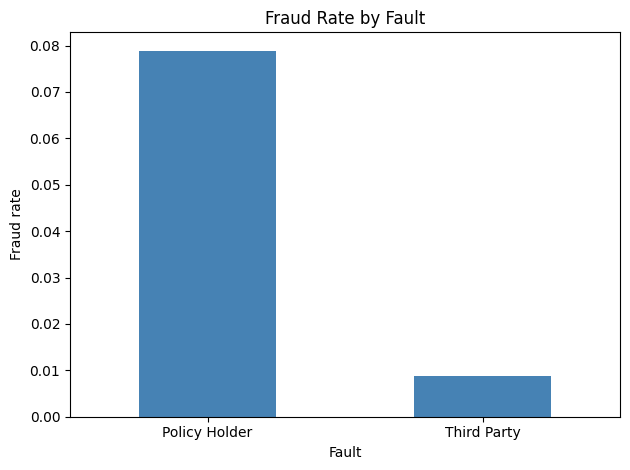

In [ ]:
fig, ax = plt.subplots()
df.groupby("Fault")[TARGET].mean().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Fault")
ax.set_ylabel("Fraud rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 6. Fraud rate by year (validating the temporal split)

The project requires a temporal hold-out split (train on earlier years, test on the most recent year) instead of random K-Fold, since the data spans 1994–1996. Before trusting that split, check that the fraud rate doesn't swing wildly year to year — a big jump would make training on the past and testing on 1996 unfair to the model.

Result: 6.7% → 5.8% → 5.2%, a gentle decline rather than a cliff, so the split is safe to use.

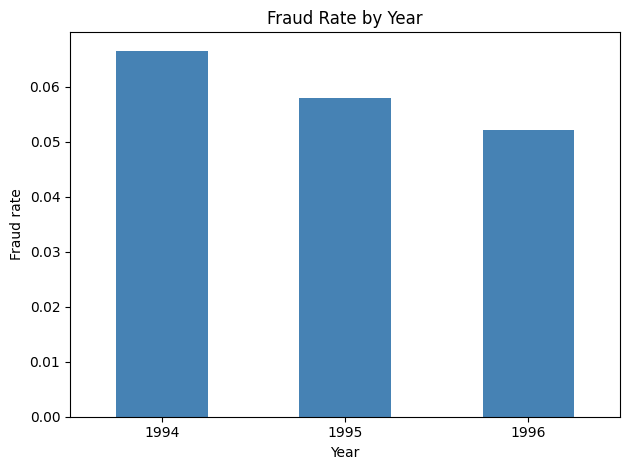

In [ ]:
fig, ax = plt.subplots()
df.groupby("Year")[TARGET].mean().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Year")
ax.set_ylabel("Fraud rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

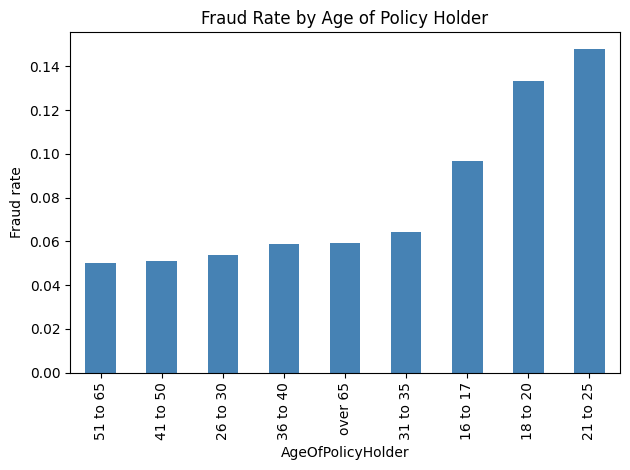

In [ ]:
fig, ax = plt.subplots()
df.groupby("AgeOfPolicyHolder")[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Age of Policy Holder")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

## 7. Fraud rate by policy type

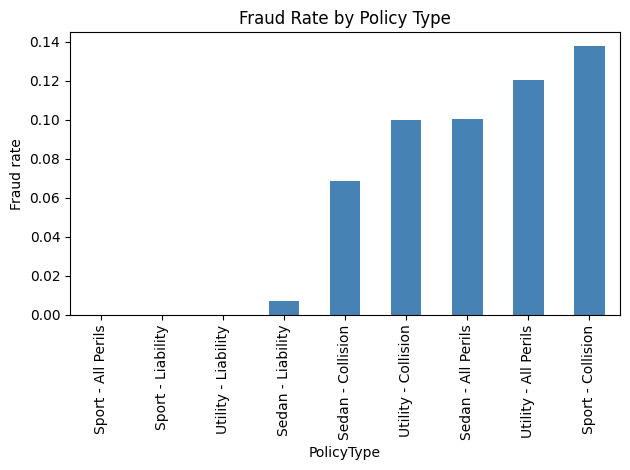

In [ ]:
fig, ax = plt.subplots()
df.groupby("PolicyType")[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Policy Type")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

## 8. Fraud rate by Accident Area

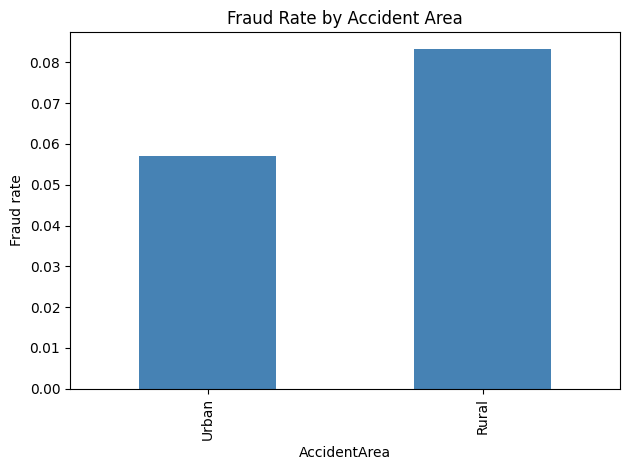

In [ ]:
fig, ax = plt.subplots()
df.groupby("AccidentArea")[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Accident Area")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

## 9. Fraud rate by Sex

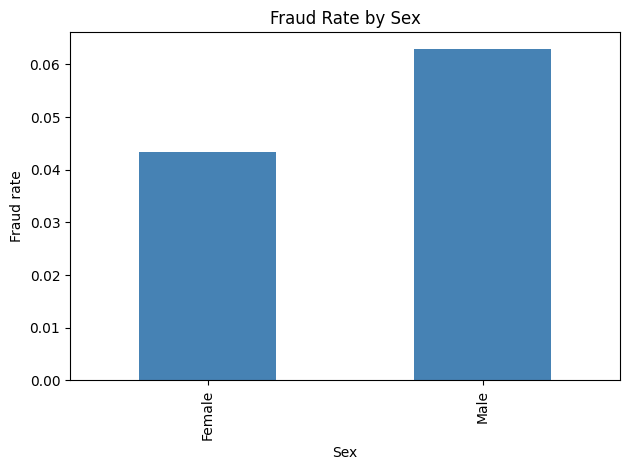

In [ ]:
fig, ax = plt.subplots()
df.groupby("Sex")[TARGET].mean().sort_values().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Fraud Rate by Sex")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

In [ ]:
# Task 3: Feature Leakage Audit
from sklearn.impute import SimpleImputer

# 1. Audit table
audit = pd.DataFrame([
    ["PoliceReportFiled",  "Possibly after submission", "Yes",      "Drop", "A report may not exist at first notice of loss"],
    ["WitnessPresent",     "Possibly after submission", "Yes",      "Drop", "Witnesses are often identified during investigation"],
    ["NumberOfSuppliments","Later in claim lifecycle",  "Yes",      "Drop", "Supplements are added as the claim is processed"],
    ["AddressChange_Claim","Depends on timing",         "Possible", "Drop (provisional)", "Unclear if recorded at submission; confirm with team"],
    ["PolicyNumber, RepNumber", "At submission",        "No",       "Drop", "Identifiers, no predictive meaning"],
    ["Year",               "At submission",             "No",       "Drop as feature", "Used for the temporal split only"],
    ["VehicleCategory, Fault", "At submission",         "No",       "Keep", "Genuine pre-investigation signal"],
], columns=["Feature", "Timing", "Leakage Risk", "Decision", "Reason"])
display(audit)

# 2. Evidence: compare model with and without the flagged features
base_drop = ["PolicyNumber", "RepNumber", "Year"]
flagged   = ["PoliceReportFiled", "WitnessPresent",
             "NumberOfSuppliments", "AddressChange_Claim"]

results_by_setup = {}
for name, drop_list in {
    "Safe (flagged dropped)": base_drop + flagged,
    "With flagged features":  base_drop,
}.items():
    Xtr = train.drop(columns=["FraudFound_P"] + drop_list)
    Xte = test.drop(columns=["FraudFound_P"] + drop_list)
    num = Xtr.select_dtypes("number").columns.tolist()
    cat = Xtr.select_dtypes(exclude="number").columns.tolist()
    m = Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("sc", StandardScaler())]), num),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])),
        ("clf", LogisticRegression(max_iter=1000))])
    m.fit(Xtr, train["FraudFound_P"])
    p = m.predict_proba(Xte)[:, 1]
    results_by_setup[name] = {
        "PR-AUC":  average_precision_score(test["FraudFound_P"], p),
        "Top 10%": capture_rate(test["FraudFound_P"], p, 0.10),
        "Top 20%": capture_rate(test["FraudFound_P"], p, 0.20),
    }

display(pd.DataFrame(results_by_setup).T.round(3))

,Feature,Timing,Leakage Risk,Decision,Reason
0,PoliceReportFiled,Possibly after submission,Yes,Drop,A report may not exist at first notice of loss
1,WitnessPresent,Possibly after submission,Yes,Drop,Witnesses are often identified during investig...
2,NumberOfSuppliments,Later in claim lifecycle,Yes,Drop,Supplements are added as the claim is processed
3,AddressChange_Claim,Depends on timing,Possible,Drop (provisional),Unclear if recorded at submission; confirm wit...
4,"PolicyNumber, RepNumber",At submission,No,Drop,"Identifiers, no predictive meaning"
5,Year,At submission,No,Drop as feature,Used for the temporal split only
6,"VehicleCategory, Fault",At submission,No,Keep,Genuine pre-investigation signal


,PR-AUC,Top 10%,Top 20%
Safe (flagged dropped),0.095,0.155,0.347
With flagged features,0.100,0.160,0.324


In [ ]:
# Task 5: Baseline Logistic Regression
from sklearn.metrics import classification_report

drop_cols = ["PolicyNumber", "RepNumber", "Year",
             "PoliceReportFiled", "WitnessPresent",
             "NumberOfSuppliments", "AddressChange_Claim"]

X_train = train.drop(columns=["FraudFound_P"] + drop_cols)
y_train = train["FraudFound_P"]
X_test  = test.drop(columns=["FraudFound_P"] + drop_cols)
y_test  = test["FraudFound_P"]

num_cols = X_train.select_dtypes("number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

model = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])),
    ("clf", LogisticRegression(max_iter=1000)),
])
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print(classification_report(y_test, preds, digits=3))
print("PR-AUC:", round(average_precision_score(y_test, probs), 3))
print("Random-guess PR-AUC:", round(y_test.mean(), 3))
for frac in [0.10, 0.20]:
    cap = capture_rate(y_test, probs, frac)
    print(f"Top {frac:.0%}: catches {cap:.1%} of fraud (lift {cap/frac:.2f}x)")

              precision    recall  f1-score   support

           0      0.948     1.000     0.973      3870
           1      0.000     0.000     0.000       213

    accuracy                          0.948      4083
   macro avg      0.474     0.500     0.487      4083
weighted avg      0.898     0.948     0.922      4083

PR-AUC: 0.095
Random-guess PR-AUC: 0.052
Top 10%: catches 15.5% of fraud (lift 1.55x)
Top 20%: catches 34.7% of fraud (lift 1.74x)


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
rep = classification_report(y_test, preds, output_dict=True)["1"]
results = pd.DataFrame({
    "Metric": ["Precision (fraud)", "Recall (fraud)", "F1 (fraud)", "PR-AUC",
               "Fraud caught in top 10%", "Fraud caught in top 20%"],
    "Baseline LogReg": [rep["precision"], rep["recall"], rep["f1-score"],
                        average_precision_score(y_test, probs),
                        capture_rate(y_test, probs, 0.10),
                        capture_rate(y_test, probs, 0.20)],
}).round(3)
results

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Baseline LogReg
0,Precision (fraud),0.000
1,Recall (fraud),0.000
2,F1 (fraud),0.000
3,PR-AUC,0.095
4,Fraud caught in top 10%,0.155
5,Fraud caught in top 20%,0.347


## Summary of Task 3

- Data is clean (no missing values) and the class imbalance is real (~6% fraud) — accuracy is not a usable metric.
- `VehicleCategory` and `Fault` carry genuine pre-investigation signal and are safe to keep.
- Fraud rate is stable enough across 1994–1996 to justify a temporal train/test split.


# Summary of Task 5

We built a simple baseline model (logistic regression) to predict fraud. It learned from 1994-1995 claims and was tested on 1996 claims. We only used information we would know when a claim is first filed.

With the default settings, the model never labeled a claim as fraud, so precision and recall were 0. That's expected because only about 5% of claims are fraud. But when we ranked claims from most to least risky, the model did better than random guessing. If investigators reviewed the top 10% of claims, they would catch about 15.5% of the fraud. For the top 20%, they would catch about 34.7%.

This gives us a starting point. In October, we'll try to beat these numbers with stronger models.
